In [3]:
import os, sys, math, random, numpy as np
print('Python:', sys.version.split()[0])
# Ensure repo root is on sys.path
repo_root = os.getcwd()
if os.path.basename(repo_root) == 'notebooks':
    repo_root = os.path.abspath(os.path.join(repo_root, '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
try:
    import torch
    print('Torch:', torch.__version__)
except Exception as e:
    print('Torch import failed:', e)
np.random.seed(0); random.seed(0)

Python: 3.14.2
Torch: 2.9.1+cu128


In [2]:
# Quick system spec summary
import platform, psutil, torch
uname = platform.uname()
print("System:", uname.system, uname.release, uname.version)
print("Machine:", uname.machine)
print("CPU:", uname.processor)
print("Logical cores:", psutil.cpu_count(logical=True))
print("Physical cores:", psutil.cpu_count(logical=False))
vm = psutil.virtual_memory()
print(f"RAM: {vm.total/1e9:.2f} GB total, {vm.available/1e9:.2f} GB available")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}, VRAM total: {gpu.total_memory/1e9:.2f} GB")
else:
    print("GPU: CUDA not available")

System: Linux 6.17.12-300.fc43.x86_64 #1 SMP PREEMPT_DYNAMIC Sat Dec 13 05:06:24 UTC 2025
Machine: x86_64
CPU: 
Logical cores: 16
Physical cores: 8
RAM: 67.14 GB total, 51.14 GB available
GPU: NVIDIA GeForce RTX 3080 Laptop GPU, VRAM total: 16.76 GB


In [4]:
# Torch QH Q-Learning training on Castaway MDP (batched) with Policy Export
import math, random, time
import numpy as np
import torch
import pandas as pd  # Do zapisu wyników
import itertools
from tqdm import trange
import matplotlib.pyplot as plt
import os

from src.algorithms.qh_qlearning_torch import QHQLearningTorch

# --- 1. KONFIGURACJA MODELU (M=10, Rain=50%, nowe akcje) ---
_device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {_device}")

M = 10           # Pojemność magazynu
H_MAX = 5
D_MAX = 15       # wyspa zalewa po 15 dniach

N_F = M + 1      # 11 stanów (0..10)
N_W = M + 1      # 11 stanów (0..10)
N_H = H_MAX + 1
N_D = D_MAX + 1

# Stride calculation for encoding
NF, NW, NH, ND = int(N_F), int(N_W), int(N_H), int(N_D)
_stride_w = NH * ND
_stride_f = NW * _stride_w

def encode_state_indices(f, w, h, d):
    return int(f * _stride_f + w * _stride_w + h * ND + d)

def decode_state(s_idx: int):
    f = s_idx // _stride_f
    rem = s_idx % _stride_f
    w = rem // _stride_w
    rem2 = rem % _stride_w
    h = rem2 // ND
    d = rem2 % ND
    return int(f), int(w), int(h), int(d)

# Definicja akcji
MODES = ['wait', 'hunt']
RATIONS = [0, 1, 2]
ACTIONS = list(itertools.product(MODES, RATIONS, RATIONS))
ACTIONS.append(('expedition', 0, 0))  # koszt 7/7, h>=3, szansa zależna od zdrowia
NUM_ACTIONS = len(ACTIONS)

# Parametry śmierci (survival probability by health)
survival_prob_by_health = [0.0, 0.5, 0.75, 0.9, 0.95, 0.99]

def sample_transition(state_idx, action_idx):
    f, w, h, d = decode_state(state_idx)

    if h == 0 or d >= D_MAX:
        return state_idx, 0.0, True

    mode, target_rf, target_rw = ACTIONS[action_idx]

    # FAZA A: pogoda (50% deszcz; jeśli pada, +2 lub +3 wody po równo)
    if np.random.rand() < 0.5:
        rain_add = 2 if np.random.rand() < 0.5 else 3
        w = min(M, w + rain_add)

    # FAZA B: akcja
    if mode == 'expedition':
        if f >= 7 and w >= 7 and h >= 3:
            surplus_pairs = max(0, min(f - 7, w - 7))  # dodatkowe zapasy ponad wymagane 7/7
            f -= 7; w -= 7
            if h == 3:
                p_base = 0.45  
            elif h == 4:
                p_base = 0.65
            else:
                p_base = 0.80
            p_bonus = min(0.15, 0.03 * surplus_pairs)  # +2pp za każdą parę nadwyżki (max +10pp)
            p_rescue = min(0.95, p_base + p_bonus)
            if np.random.rand() < p_rescue:
                return encode_state_indices(f, w, h, d + 1), 50.0, True
            else:
                # Ekspedycja nieudana → śmierć
                return encode_state_indices(f, w, 0, d + 1), -100.0, True
    elif mode == 'hunt':
        if f >= 1 and w >= 1:
            f -= 1; w -= 1
            p_succ = 0.3 + 0.08 * h
            if np.random.rand() < p_succ:
                f = min(M, f + 3)
    # wait nie ma dodatkowej logiki

    # FAZA C: konsumpcja i zdrowie
    cf = min(target_rf, f)
    cw = min(target_rw, w)
    f -= cf; w -= cw

    if cf >= 2 and cw >= 2:
        delta_h = 1
    elif cf >= 1 and cw >= 1:
        delta_h = 0
    elif cf == 0 and cw == 0:
        delta_h = -2
    else:
        delta_h = -1

    h = max(0, min(H_MAX, h + delta_h))

    reward = math.log1p(cf) + math.log1p(cw)
    reward *= (1.0 + (h / H_MAX) ** 2)  # skalowanie nagrody zdrowiem

    # FAZA ŚMIERCI
    if h == 0:
        return encode_state_indices(f, w, h, d + 1), reward - 100.0, True

    survival_p = survival_prob_by_health[h]
    if np.random.rand() > survival_p:
        return encode_state_indices(f, w, 0, d + 1), reward - 100.0, True

    # FAZA RATUNKU LOSOWEGO (7% dziennie)
    if np.random.rand() < 0.07:
        return encode_state_indices(f, w, h, d + 1), reward + 50.0, True

    # ZALEWANIE WYSPY PO 15 DNIACH
    if d + 1 >= D_MAX:
        return encode_state_indices(f, w, h, d + 1), reward - 100.0, True

    return encode_state_indices(f, w, h, d + 1), reward, False

# --- 3. PRZYGOTOWANIE AGENTA ---
A = int(NUM_ACTIONS)
S = int(NF * NW * NH * ND)
mask = np.zeros((S, A), dtype=bool)

print("Generating feasibility mask...")
for s_idx in range(S):
    f, w, h, d = decode_state(s_idx)
    if h == 0:
        continue
    for a_idx, (mode, eat, drink) in enumerate(ACTIONS):
        feasible = (eat <= f) and (drink <= w)
        if mode == 'hunt':
            feasible = feasible and (f - eat >= 1) and (w - drink >= 1)
        elif mode == 'expedition':
            feasible = (f >= 7) and (w >= 7) and (h >= 3)
        mask[s_idx, a_idx] = feasible

torch_mask = torch.tensor(mask, device=_device)

t_agent = QHQLearningTorch(
    n_states=int(S),
    n_actions=int(A),
    alpha=0.6,
    beta=0.95,
    theta_step=0.2,
    eta_step=0.5,
    step_offset=20000.0,
    theta_power=0.6,
    eta_power=0.6,
    init_value=0.0,
    device=_device,
 )

eps_start, eps_end, eps_decay = 0.3, 0.05, 5000
def epsilon(t):
    if t >= eps_decay:
        return eps_end
    return eps_start + (eps_end - eps_start) * (t / eps_decay)

# --- 4. TRENING (opcjonalny, szybki warm-up) ---
# Ustaw na True, by wykonać 100k batchy; domyślnie pomijamy, aby nie tracić 2h
RUN_TORCH_TRAINING = False
DEFAULT_NUM_BATCHES = 300000
DEFAULT_BATCH_SIZE = 4096
DEFAULT_LOG_INTERVAL = 50

# Śledzenie konkretnego stanu
(target_f, target_w, target_h, target_d) = (5, 10, 3, 0)
probe_idx = encode_state_indices(target_f, target_w, target_h, target_d)

num_batches = DEFAULT_NUM_BATCHES
batch_size = DEFAULT_BATCH_SIZE
log_interval = DEFAULT_LOG_INTERVAL
rng = np.random.default_rng(123)
history_batches = []
history_probe_q = []
history_probe_w = []
history_probe_q_full = []  # pełny wektor Q dla stanu probe
history_probe_w_full = []  # pełny wektor W dla stanu probe

def log_probe_rows():
    with torch.no_grad():
        row_q = t_agent.Q[probe_idx].clone()
        row_w = t_agent.W[probe_idx].clone() if hasattr(t_agent, 'W') else None

        row_q_masked = row_q.clone(); row_q_masked[~torch_mask[probe_idx]] = -float('inf')
        history_probe_q.append(row_q_masked.max().item())

        row_q_np = row_q.detach().cpu().numpy(); row_q_np[~mask[probe_idx]] = np.nan
        history_probe_q_full.append(row_q_np.copy())

        if row_w is not None:
            row_w_masked = row_w.clone(); row_w_masked[~torch_mask[probe_idx]] = -float('inf')
            history_probe_w.append(row_w_masked.max().item())
            row_w_np = row_w.detach().cpu().numpy(); row_w_np[~mask[probe_idx]] = np.nan
            history_probe_w_full.append(row_w_np.copy())

def plot_probe_history():
    if not history_batches:
        print("No probe history to plot.")
        return
    plt.figure(figsize=(10, 6))
    plt.plot(history_batches, history_probe_q, label='Q', color='blue')
    if history_probe_w:
        plt.plot(history_batches, history_probe_w, label='W', color='orange', linestyle='--')
    plt.title(f"Wartości Q/W dla stanu F={target_f}, W={target_w}, H={target_h}, D={target_d}")
    plt.xlabel("Batch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def run_torch_training(num_batches=num_batches, batch_size=batch_size, log_interval=log_interval, seed=123, export=True):
    rng = np.random.default_rng(seed)
    history_batches.clear(); history_probe_q.clear(); history_probe_w.clear(); history_probe_q_full.clear(); history_probe_w_full.clear()
    print("Starting training (short run)...")
    start = time.time()
    for b in trange(num_batches, desc="QHQL Training"):
        e = epsilon(b)

        states = rng.integers(low=0, high=S, size=(batch_size,), dtype=np.int64)
        actions = np.empty((batch_size,), dtype=np.int64)
        rewards = np.empty((batch_size,), dtype=np.float32)
        next_states = np.empty((batch_size,), dtype=np.int64)
        dones = np.empty((batch_size,), dtype=np.bool_)

        for i, s_idx in enumerate(states):
            feasible_actions = np.flatnonzero(mask[s_idx])
            if feasible_actions.size == 0:
                a_idx = 0
            else:
                if rng.random() < e:
                    a_idx = int(rng.choice(feasible_actions))
                else:
                    q_row = t_agent.Q[s_idx].detach().cpu().numpy()
                    a_idx = int(feasible_actions[np.argmax(q_row[feasible_actions])])
            ns, r, done = sample_transition(int(s_idx), int(a_idx))
            actions[i] = a_idx
            rewards[i] = r
            next_states[i] = ns
            dones[i] = done

        t_agent.update_batch(states, actions, rewards, next_states, dones=dones, available_actions_mask=mask)

        if b % log_interval == 0:
            history_batches.append(b)
            log_probe_rows()

    end = time.time()
    print(f"Training finished in {end-start:.1f}s")
    if export:
        export_policies()
        save_probe_history()
    plot_probe_history()


def export_policies(filename="castaway_optimal_policies.csv"):
    print("\nExtracting optimal policies (Mu and Phi)...")

    policy_data = []
    Q_cpu = t_agent.Q.detach().cpu().numpy()
    W_cpu = t_agent.W.detach().cpu().numpy()

    for s_idx in range(S):
        f, w, h, d = decode_state(s_idx)
        if h == 0:
            continue

        feasible = np.flatnonzero(mask[s_idx])
        if feasible.size == 0:
            continue

        q_vals = Q_cpu[s_idx]
        best_mu_idx = feasible[np.argmax(q_vals[feasible])]
        mu_mode, mu_eat, mu_drink = ACTIONS[best_mu_idx]
        mu_val = q_vals[best_mu_idx]

        w_vals = W_cpu[s_idx]
        best_phi_idx = feasible[np.argmax(w_vals[feasible])]
        phi_mode, phi_eat, phi_drink = ACTIONS[best_phi_idx]
        phi_val = w_vals[best_phi_idx]

        policy_data.append({
            'State_ID': s_idx,
            'F': f,
            'W': w,
            'H': h,
            'D': d,
            'Mu_Mode': mu_mode,
            'Mu_Eat': mu_eat,
            'Mu_Drink': mu_drink,
            'Q_Value': round(mu_val, 4),
            'Phi_Mode': phi_mode,
            'Phi_Eat': phi_eat,
            'Phi_Drink': phi_drink,
            'W_Value': round(phi_val, 4),
            'Conflict': best_mu_idx != best_phi_idx
        })

    df_policy = pd.DataFrame(policy_data)
    df_policy.to_csv(filename, index=False)

    print(f"Policies saved to {filename}")
    print(f"Total states analyzed: {len(df_policy)}")
    print(f"States with Time-Inconsistency (Mu != Phi): {df_policy['Conflict'].sum()}")

    probe_row = df_policy[df_policy['State_ID'] == probe_idx].iloc[0]
    print("\n--- PROBE STATE ANALYSIS ---")
    print(f"State: F={probe_row['F']}, W={probe_row['W']}, H={probe_row['H']}, D={probe_row['D']}")
    print(f"Mu (Impulsive): {probe_row['Mu_Mode']} [E:{probe_row['Mu_Eat']}, D:{probe_row['Mu_Drink']}] (Q={probe_row['Q_Value']})")
    print(f"Phi (Planned):  {probe_row['Phi_Mode']} [E:{probe_row['Phi_Eat']}, D:{probe_row['Phi_Drink']}] (W={probe_row['W_Value']})")
    if probe_row['Conflict']:
        print(">>> CONFLICT DETECTED: Agent wants to do Mu now, but planned Phi!")
    else:
        print(">>> No Conflict: Agent is consistent here.")

    if history_batches:
        plt.figure(figsize=(10, 6))
        plt.plot(history_batches, history_probe_q, label='Q', color='blue')
        if history_probe_w:
            plt.plot(history_batches, history_probe_w, label='W', color='orange', linestyle='--')
        plt.title(f"WartośćQ i W dla stanu startowego woda={target_w}, jedzenie={target_f}, zdrowie={target_h}, dzień={target_d}")
        plt.xlabel("Iteracje")
        plt.ylabel("Wartość")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

def save_probe_history(filename="probe_qw_history.csv"):
    """Zapisuje pełne wektory Q/W dla stanu probe w kolejnych log pointach."""
    if not history_batches:
        print("No probe history to save.")
        return
    data = []
    for step_idx, b in enumerate(history_batches):
        q_vec = history_probe_q_full[step_idx]
        w_vec = history_probe_w_full[step_idx] if step_idx < len(history_probe_w_full) else None
        for a_idx in range(NUM_ACTIONS):
            data.append({
                "batch": b,
                "action_idx": a_idx,
                "action": ACTIONS[a_idx],
                "Q": float(q_vec[a_idx]) if not np.isnan(q_vec[a_idx]) else np.nan,
                "W": float(w_vec[a_idx]) if (w_vec is not None and not np.isnan(w_vec[a_idx])) else np.nan
            })
    pd.DataFrame(data).to_csv(filename, index=False)
    print(f"Probe Q/W history saved to {filename}")

if RUN_TORCH_TRAINING:
    run_torch_training()
else:
    print("Skipping short-run torch training; use train_long_run() or set RUN_TORCH_TRAINING=True if needed.")

Device: cuda
Generating feasibility mask...
Skipping short-run torch training; use train_long_run() or set RUN_TORCH_TRAINING=True if needed.


In [5]:
# Batch size prober (GPU/CPU) + long-run training helper
import psutil

def probe_max_batch(device='cuda', start=4096, max_pow=18, shape_per_item=1):
    """
    Heurystycznie sprawdza największy batch, który mieści się w pamięci.
    Tworzy losowy tensor float32 o kształcie (batch, shape_per_item) na wskazanym urządzeniu
    i sprawdza, gdzie pojawia się OOM.
    """
    if device == 'cuda' and not torch.cuda.is_available():
        print("CUDA not available; falling back to CPU probe.")
        device = 'cpu'
    results = []
    for p in range(int(np.log2(start)), max_pow + 1):
        b = 2 ** p
        try:
            if device == 'cuda':
                torch.cuda.empty_cache()
            _ = torch.empty((b, shape_per_item), device=device, dtype=torch.float32)
            if device == 'cuda':
                torch.cuda.synchronize()
            results.append((b, True))
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                results.append((b, False))
                break
            else:
                raise
        finally:
            del _
    print(f"Probe results on {device}: {results}")
    ok = [b for b, ok in results if ok]
    return max(ok) if ok else start

# Szybkie metryki pamięci
if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu_props.name}, VRAM total: {gpu_props.total_memory/1e9:.2f} GB")
print(f"CPU RAM: {psutil.virtual_memory().total/1e9:.2f} GB")

# Uruchom próbę: shape_per_item ~ liczba cech potrzebnych w update (tu 1 wystarczy)
max_batch_cuda = probe_max_batch(device='cuda' if torch.cuda.is_available() else 'cpu', start=4096, max_pow=19)
print(f"Suggested max batch: {max_batch_cuda}")

# Long-run training helper (konfig): dostosuj num_batches/batch_size tu
long_run_config = {
    'num_batches': 160_000,
    'batch_size': min(max_batch_cuda, 4096*4),  # duży batch, docelowo 65536
    'log_interval': 200,
    'checkpoint_every': 5_000,
    'checkpoint_path': 'qhq_torch_checkpoint2.pt'
}
print("Long-run config:", long_run_config)

# Opcjonalny szkic pętli z checkpointami (nie uruchamiam automatycznie)
def train_long_run(cfg=long_run_config):
    ckpt_path = cfg['checkpoint_path']
    start_batch = 0
    if os.path.exists(ckpt_path):
        data = torch.load(ckpt_path, map_location=_device)
        t_agent.Q.copy_(data['Q'])
        t_agent.W.copy_(data['W'])
        start_batch = data.get('batch', 0)
        print(f"Loaded checkpoint from {ckpt_path} at batch {start_batch}")
    rng = np.random.default_rng(1234)
    history_batches.clear(); history_probe_q.clear(); history_probe_w.clear(); history_probe_q_full.clear(); history_probe_w_full.clear()

    for b in trange(start_batch, cfg['num_batches'], desc="QHQL Long-Run"):
        e = epsilon(b)
        states = rng.integers(low=0, high=S, size=(cfg['batch_size'],), dtype=np.int64)
        actions = np.empty((cfg['batch_size'],), dtype=np.int64)
        rewards = np.empty((cfg['batch_size'],), dtype=np.float32)
        next_states = np.empty((cfg['batch_size'],), dtype=np.int64)
        dones = np.empty((cfg['batch_size'],), dtype=np.bool_)

        for i, s_idx in enumerate(states):
            feasible_actions = np.flatnonzero(mask[s_idx])
            if feasible_actions.size == 0:
                a_idx = 0
            else:
                if rng.random() < e:
                    a_idx = int(rng.choice(feasible_actions))
                else:
                    q_row = t_agent.Q[s_idx].detach().cpu().numpy()
                    a_idx = int(feasible_actions[np.argmax(q_row[feasible_actions])])
            ns, r, done = sample_transition(int(s_idx), int(a_idx))
            actions[i] = a_idx; rewards[i] = r; next_states[i] = ns; dones[i] = done

        t_agent.update_batch(states, actions, rewards, next_states, dones=dones, available_actions_mask=mask)

        if b % cfg['log_interval'] == 0:
            history_batches.append(b)
            log_probe_rows()
        if b % cfg['checkpoint_every'] == 0 and b > start_batch:
            torch.save({'Q': t_agent.Q.cpu(), 'W': t_agent.W.cpu(), 'batch': b}, ckpt_path)
            print(f"Checkpoint saved at batch {b} -> {ckpt_path}")

    torch.save({'Q': t_agent.Q.cpu(), 'W': t_agent.W.cpu(), 'batch': cfg['num_batches']}, ckpt_path)
    print(f"Training complete. Final checkpoint at {ckpt_path}")
    save_probe_history()
    plot_probe_history()

# Aby uruchomić: train_long_run()

GPU: NVIDIA GeForce RTX 3080 Laptop GPU, VRAM total: 16.76 GB
CPU RAM: 67.14 GB
Probe results on cuda: [(4096, True), (8192, True), (16384, True), (32768, True), (65536, True), (131072, True), (262144, True), (524288, True)]
Suggested max batch: 524288
Long-run config: {'num_batches': 160000, 'batch_size': 16384, 'log_interval': 200, 'checkpoint_every': 5000, 'checkpoint_path': 'qhq_torch_checkpoint2.pt'}


In [81]:
# Start long-run training with current config
train_long_run()

Loaded checkpoint from qhq_torch_checkpoint2.pt at batch 160000


QHQL Long-Run: 0it [00:00, ?it/s]

Training complete. Final checkpoint at qhq_torch_checkpoint2.pt
No probe history to save.
No probe history to plot.


In [36]:
# Monte Carlo runner (patched) with environment-consistency checks

def run_simulation_from_csv(policy_type='Mu', n_sims=5000, start_state=None, verbose=False):
    """Monte Carlo simulation using the same environment as training.

    This function performs runtime checks to ensure that key environment
    parameters used during training are present and consistent:
    - number of actions (`NUM_ACTIONS` vs `len(ACTIONS)`)
    - state/action mask shape (`mask.shape`) matches `S x A`
    - domain parameters `D_MAX`, `M`, `H_MAX` are available
    - if a trained agent `t_agent` or arrays `Q_arr`/`W_arr` exist, their shapes
      are consistent with `S` and `A`.

    If checks pass, runs the simulation and returns per-day outcomes and
    action usage (including per-day counts for expedition/hunt).
    """
    # --- Environment consistency checks ---
    # Basic parameters
    if 'NUM_ACTIONS' in globals() and 'ACTIONS' in globals():
        if NUM_ACTIONS != len(ACTIONS):
            raise RuntimeError(f"NUM_ACTIONS ({NUM_ACTIONS}) disagrees with len(ACTIONS) ({len(ACTIONS)})")
    if 'S' in globals() and 'mask' in globals():
        if mask.shape[0] != S:
            raise RuntimeError(f"Mask shape ({mask.shape}) inconsistent with S={S}")
    if 'S' in globals() and 'NUM_ACTIONS' in globals() and 'mask' in globals():
        if mask.shape[1] != NUM_ACTIONS:
            raise RuntimeError(f"Mask shape ({mask.shape}) inconsistent with NUM_ACTIONS={NUM_ACTIONS}")
    # Domain parameters
    for varname in ('D_MAX','M','H_MAX'):
        if varname not in globals():
            raise RuntimeError(f"Required environment parameter {varname} is not defined in the notebook")
    # Trained agent / arrays consistency (best-effort)
    if 't_agent' in globals() and hasattr(t_agent, 'Q'):
        qshape = tuple(t_agent.Q.shape)
        if qshape[0] != S:
            raise RuntimeError(f"Trained agent Q has {qshape[0]} states, expected S={S}")
        if qshape[1] != NUM_ACTIONS:
            raise RuntimeError(f"Trained agent Q has {qshape[1]} actions, expected NUM_ACTIONS={NUM_ACTIONS}")
    if 'Q_arr' in globals():
        if Q_arr.shape != (S, NUM_ACTIONS):
            print(f"Warning: Q_arr.shape={Q_arr.shape} differs from (S,NUM_ACTIONS)=({S},{NUM_ACTIONS})")
    if 'W_arr' in globals():
        if W_arr.shape != (S, NUM_ACTIONS):
            print(f"Warning: W_arr.shape={W_arr.shape} differs from (S,NUM_ACTIONS)=({S},{NUM_ACTIONS})")

    # Proceed with simulation (policy selection follows)
    if policy_type == 'Mu':
        policy_dict = mu_policy
        policy_name = "Impulsive (Mu-Policy)"
    elif policy_type == 'Phi':
        policy_dict = phi_policy
        policy_name = "Planned (Phi-Policy)"
    elif policy_type == 'MuThenPhi':
        policy_dict = {'Mu': mu_policy, 'Phi': phi_policy}
        policy_name = "Mixed (Mu day0, Phi later)"
    elif policy_type == 'Baseline':
        policy_dict = baseline_policy
        policy_name = "Baseline (Always Wait 1/1)"
    else:
        policy_dict = None
        policy_name = "Random (uniform feasible)"

    # Tablice wynikowe
    death_counts = np.zeros(D_MAX + 2, dtype=int)
    rescue_counts = np.zeros(D_MAX + 2, dtype=int)
    expedition_count = 0
    hunt_count = 0
    expedition_by_day = np.zeros(D_MAX + 2, dtype=int)
    hunt_by_day = np.zeros(D_MAX + 2, dtype=int)
    rng = np.random.default_rng(12345)

    for sim_idx in range(n_sims):
        f, w, h, d = start_state if start_state is not None else (5, 10, 3, 0)
        s = encode_state_indices(f, w, h, d)

        while True:
            # wybór akcji
            if policy_type == 'MuThenPhi':
                _, _, _, d_curr_check = decode_state(s)
                chosen_dict = policy_dict['Mu'] if d_curr_check == 0 else policy_dict['Phi']
                if s not in chosen_dict:
                    break
                mode, eat, drink = chosen_dict[s]
            elif policy_type != 'Random':
                if s not in policy_dict:
                    break
                mode, eat, drink = policy_dict[s]
            else:
                feasible = np.flatnonzero(mask[s])
                if feasible.size == 0:
                    break
                a_idx = int(rng.choice(feasible))
                mode, eat, drink = ACTIONS[a_idx]

            # zapamiętaj bieżący dzień akcji
            d_curr = decode_state(s)[3]

            # liczniki akcji
            if mode == 'expedition':
                expedition_count += 1
                expedition_by_day[min(d_curr, D_MAX + 1)] += 1
            elif mode == 'hunt':
                hunt_count += 1
                hunt_by_day[min(d_curr, D_MAX + 1)] += 1

            action_idx = ACTIONS.index((mode, eat, drink))

            # wykonanie kroku
            next_s, reward, done = sample_transition(int(s), int(action_idx))
            f_next, w_next, h_next, d_next = decode_state(next_s)

            # Ustal dzień zdarzenia (expedition -> d_curr, else d_next)
            if done and mode == 'expedition':
                d_log = min(d_curr, D_MAX + 1)
            else:
                d_log = min(d_next, D_MAX + 1)

            # Śmierć z powodu utraty zdrowia
            if h_next == 0:
                death_counts[d_log] += 1
                if verbose and sim_idx < 3:
                    print(f"  Sim {sim_idx}: Died (Health=0) on day {d_log}")
                break

            if done:
                # upływ czasu / przekroczenie D_MAX
                if d_next >= D_MAX:
                    death_counts[d_log] += 1
                    if verbose and sim_idx < 3:
                        print(f"  Sim {sim_idx}: Died (Time limit) on day {d_log}")
                else:
                    rescue_counts[d_log] += 1
                    if verbose and sim_idx < 3:
                        print(f"  Sim {sim_idx}: RESCUED on day {d_log}")
                break

            # kontynuuj
            s = next_s

    # Przygotuj tabelę wyników
    results = []
    for dd in range(1, D_MAX + 2):
        total = int(death_counts[dd] + rescue_counts[dd])
        if total == 0:
            continue
        pct_death = 100 * death_counts[dd] / total
        pct_rescue = 100 * rescue_counts[dd] / total
        results.append({
            'Day': int(dd),
            'Deaths': int(death_counts[dd]),
            'Rescued': int(rescue_counts[dd]),
            'Total': int(total),
            'Death%': f'{pct_death:.1f}%',
            'Rescue%': f'{pct_rescue:.1f}%'
        })

    action_counts = {
        'expedition': int(expedition_count),
        'hunt': int(hunt_count),
        'expedition_by_day': expedition_by_day[:D_MAX + 1].copy(),
        'hunt_by_day': hunt_by_day[:D_MAX + 1].copy()
    }

    return pd.DataFrame(results), policy_name, action_counts

# End of patched run_simulation_from_csv


In [ ]:
def run_simulation_from_csv(policy_type='Mu', n_sims=5000, start_state=None, verbose=False):
    """Monte Carlo simulation with patched logging logic and rescue source breakdown."""

    # 1. Wybór polityki
    if policy_type == 'Mu':
        policy_dict = mu_policy
        policy_name = "Impulsive (Mu-Policy)"
    elif policy_type == 'Phi':
        policy_dict = phi_policy
        policy_name = "Planned (Phi-Policy)"
    elif policy_type == 'MuThenPhi':
        policy_dict = {'Mu': mu_policy, 'Phi': phi_policy}
        policy_name = "Mixed (Mu day0, Phi later)"
    elif policy_type == 'Baseline':
        policy_dict = baseline_policy
        policy_name = "Baseline (Always Wait 1/1)"
    else:
        policy_dict = None
        policy_name = "Random (uniform feasible)"

    # 2. Inicjalizacja liczników
    # Tablice o rozmiarze D_MAX + 2, by bezpiecznie indeksować dni 0..(D_MAX+1)
    death_counts = np.zeros(D_MAX + 2, dtype=int)
    rescue_counts = np.zeros(D_MAX + 2, dtype=int)  # total rescued (both sources)

    # New breakdown: expedition-success vs random-rescue
    expedition_rescue_counts = np.zeros(D_MAX + 2, dtype=int)
    random_rescue_counts = np.zeros(D_MAX + 2, dtype=int)

    expedition_count = 0
    hunt_count = 0
    expedition_by_day = np.zeros(D_MAX + 2, dtype=int)
    hunt_by_day = np.zeros(D_MAX + 2, dtype=int)

    rng = np.random.default_rng(12345)

    # 3. Pętla symulacji
    for sim_idx in range(n_sims):
        # Domyślny start: F=5, W=10, H=3, D=0
        f, w, h, d = start_state if start_state is not None else (5, 10, 3, 0)
        s = encode_state_indices(f, w, h, d)

        while True:
            # wybór akcji
            if policy_type == 'MuThenPhi':
                _, _, _, d_curr_check = decode_state(s)
                chosen_dict = policy_dict['Mu'] if d_curr_check == 0 else policy_dict['Phi']
                if s not in chosen_dict:
                    break
                mode, eat, drink = chosen_dict[s]
            elif policy_type != 'Random':
                if s not in policy_dict:
                    break
                mode, eat, drink = policy_dict[s]
            else:
                feasible = np.flatnonzero(mask[s])
                if feasible.size == 0:
                    break
                a_idx = int(rng.choice(feasible))
                mode, eat, drink = ACTIONS[a_idx]

            # zapamiętaj bieżący dzień akcji
            d_curr = decode_state(s)[3]

            # liczniki akcji
            if mode == 'expedition':
                expedition_count += 1
                expedition_by_day[min(d_curr, D_MAX + 1)] += 1
            elif mode == 'hunt':
                hunt_count += 1
                hunt_by_day[min(d_curr, D_MAX + 1)] += 1

            action_idx = ACTIONS.index((mode, eat, drink))

            # wykonanie kroku
            next_s, reward, done = sample_transition(int(s), int(action_idx))
            f_next, w_next, h_next, d_next = decode_state(next_s)

            # Ustal dzień zdarzenia (expedition -> d_curr, else d_next)
            if done and mode == 'expedition':
                d_log = min(d_curr, D_MAX + 1)
            else:
                d_log = min(d_next, D_MAX + 1)

            # Śmierć z powodu utraty zdrowia
            if h_next == 0:
                death_counts[d_log] += 1
                if verbose and sim_idx < 3:
                    print(f"  Sim {sim_idx}: Died (Health=0) on day {d_log}")
                break

            if done:
                # upływ czasu / przekroczenie D_MAX
                if d_next >= D_MAX and reward <= 0:
                    death_counts[d_log] += 1
                    if verbose and sim_idx < 3:
                        print(f"  Sim {sim_idx}: Died (Time limit) on day {d_log}")
                else:
                    # We treat positive-reward terminations as rescues.
                    rescue_counts[d_log] += 1
                    # Distinguish source: if the action was an expedition and the reward is positive => expedition success
                    if mode == 'expedition' and reward > 0:
                        expedition_rescue_counts[d_log] += 1
                        if verbose and sim_idx < 3:
                            print(f"  Sim {sim_idx}: EXPEDITION-RESCUE on day {d_log}")
                    else:
                        # Otherwise it's a random/system rescue (e.g. 7% daily rescue)
                        random_rescue_counts[d_log] += 1
                        if verbose and sim_idx < 3:
                            print(f"  Sim {sim_idx}: RANDOM-RESCUE on day {d_log}")
                break

            # kontynuuj
            s = next_s

    # Przygotuj tabelę wyników (per-day totals as before)
    results = []
    for dd in range(1, D_MAX + 2):
        total = int(death_counts[dd] + rescue_counts[dd])
        if total == 0:
            continue
        pct_death = 100 * death_counts[dd] / total
        pct_rescue = 100 * rescue_counts[dd] / total
        results.append({
            'Day': int(dd),
            'Deaths': int(death_counts[dd]),
            'Rescued': int(rescue_counts[dd]),
            'Total': int(total),
            'Death%': f'{pct_death:.1f}%',
            'Rescue%': f'{pct_rescue:.1f}%'
        })

    action_counts = {
        'expedition': int(expedition_count),
        'hunt': int(hunt_count),
        'expedition_by_day': expedition_by_day[:D_MAX + 1].copy(),
        'hunt_by_day': hunt_by_day[:D_MAX + 1].copy(),
        # Add rescue breakdown totals and per-day arrays
        'rescue_total': int(rescue_counts.sum()),
        'expedition_rescue_total': int(expedition_rescue_counts.sum()),
        'random_rescue_total': int(random_rescue_counts.sum()),
        'expedition_rescue_by_day': expedition_rescue_counts[:D_MAX + 1].copy(),
        'random_rescue_by_day': random_rescue_counts[:D_MAX + 1].copy(),
    }

    return pd.DataFrame(results), policy_name, action_counts


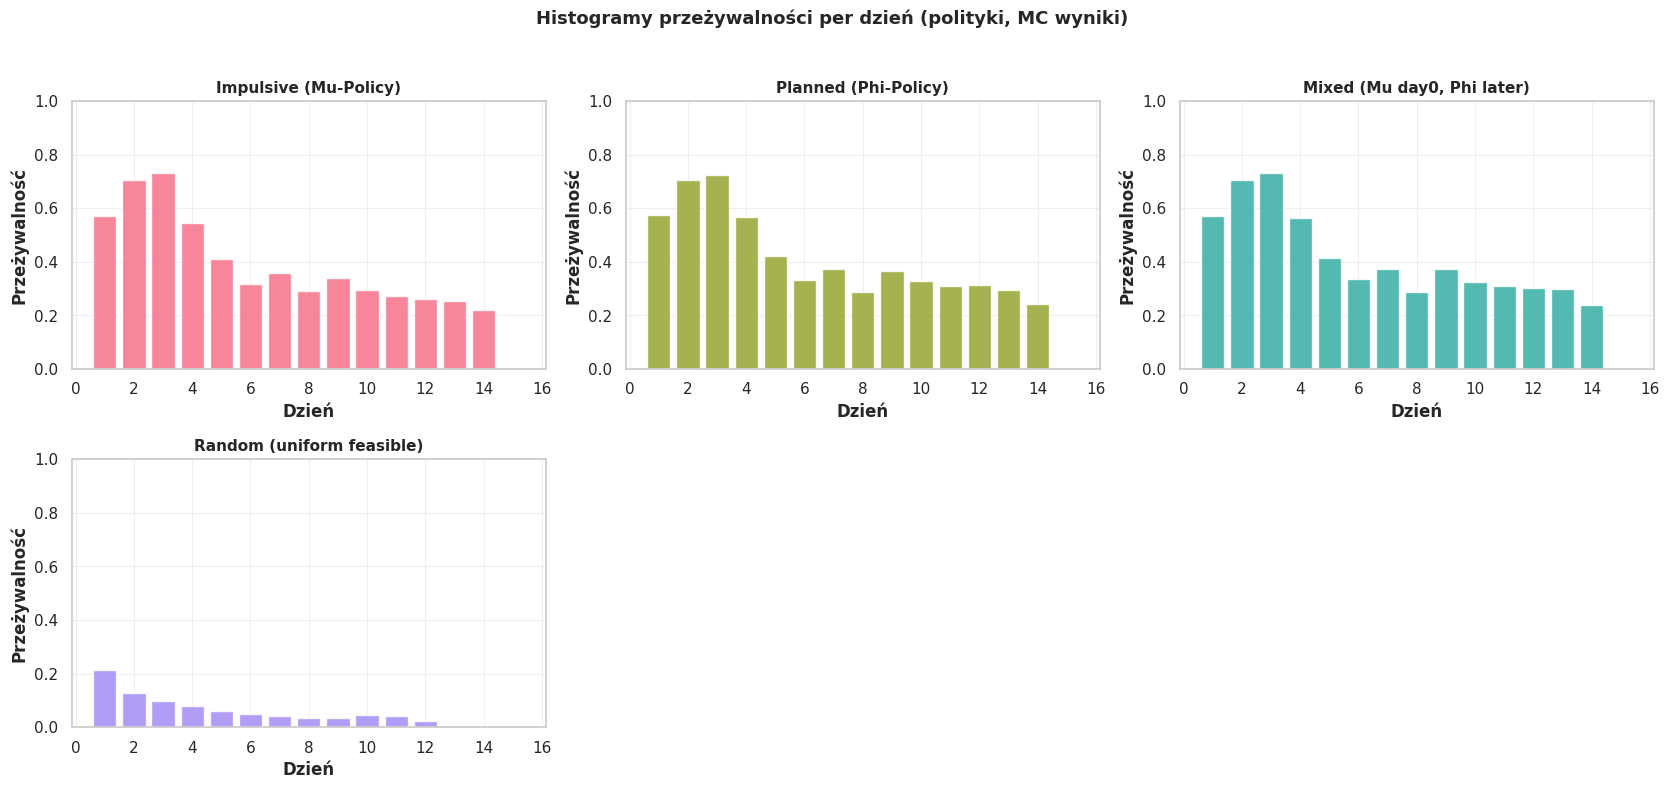

In [40]:
# Plot per-day survival histograms for policies from the Monte Carlo results
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Ensure required DataFrames exist (without baseline)
required = [
    (globals().get('policy_name_mu'), globals().get('df_results_mu')),
    (globals().get('policy_name_phi'), globals().get('df_results_phi')),
    (globals().get('policy_name_mix'), globals().get('df_results_mix')),
    (globals().get('policy_name_random'), globals().get('df_results_random')),
]
policies = [(name, df) for (name, df) in required if (name is not None and isinstance(df, pd.DataFrame) and not df.empty)]
if not policies:
    raise RuntimeError("Brak wyników Monte Carlo do rysowania. Uruchom najpierw symulację.")

# Prepare combined DataFrame with survival rate per day
frames = []
for name, df in policies:
    df2 = df.copy()
    df2['survival_rate'] = (df2['Rescued'] / df2['Total']).fillna(0.0)
    df2['policy'] = str(name)
    frames.append(df2[['Day', 'survival_rate', 'policy']])
combined = pd.concat(frames, axis=0, ignore_index=True)
combined['Day'] = combined['Day'].astype(int)

# Arrange subplots in a grid
n = len(policies)
cols = min(3, n)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5.4 * cols + 0.6, 3.8 * rows + 0.6), squeeze=False)
palette = sns.color_palette("husl", n)

# Draw one histogram per policy
for idx, (name, _) in enumerate(policies):
    ax = axes[idx // cols][idx % cols]
    dfp = combined[combined['policy'] == name]
    ax.bar(dfp['Day'], dfp['survival_rate'], color=palette[idx], alpha=0.85, width=0.8, edgecolor="#ffffff")
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Dzień', fontweight='semibold')
    ax.set_ylabel('Przeżywalność', fontweight='semibold')
    ax.set_ylim(0.0, 1.0)
    ax.set_facecolor('#ffffff')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, color='#cccccc')

# Hide any unused axes
for j in range(n, rows * cols):
    axes[j // cols][j % cols].set_visible(False)

fig.suptitle('Histogramy przeżywalności per dzień (polityki, MC wyniki)', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

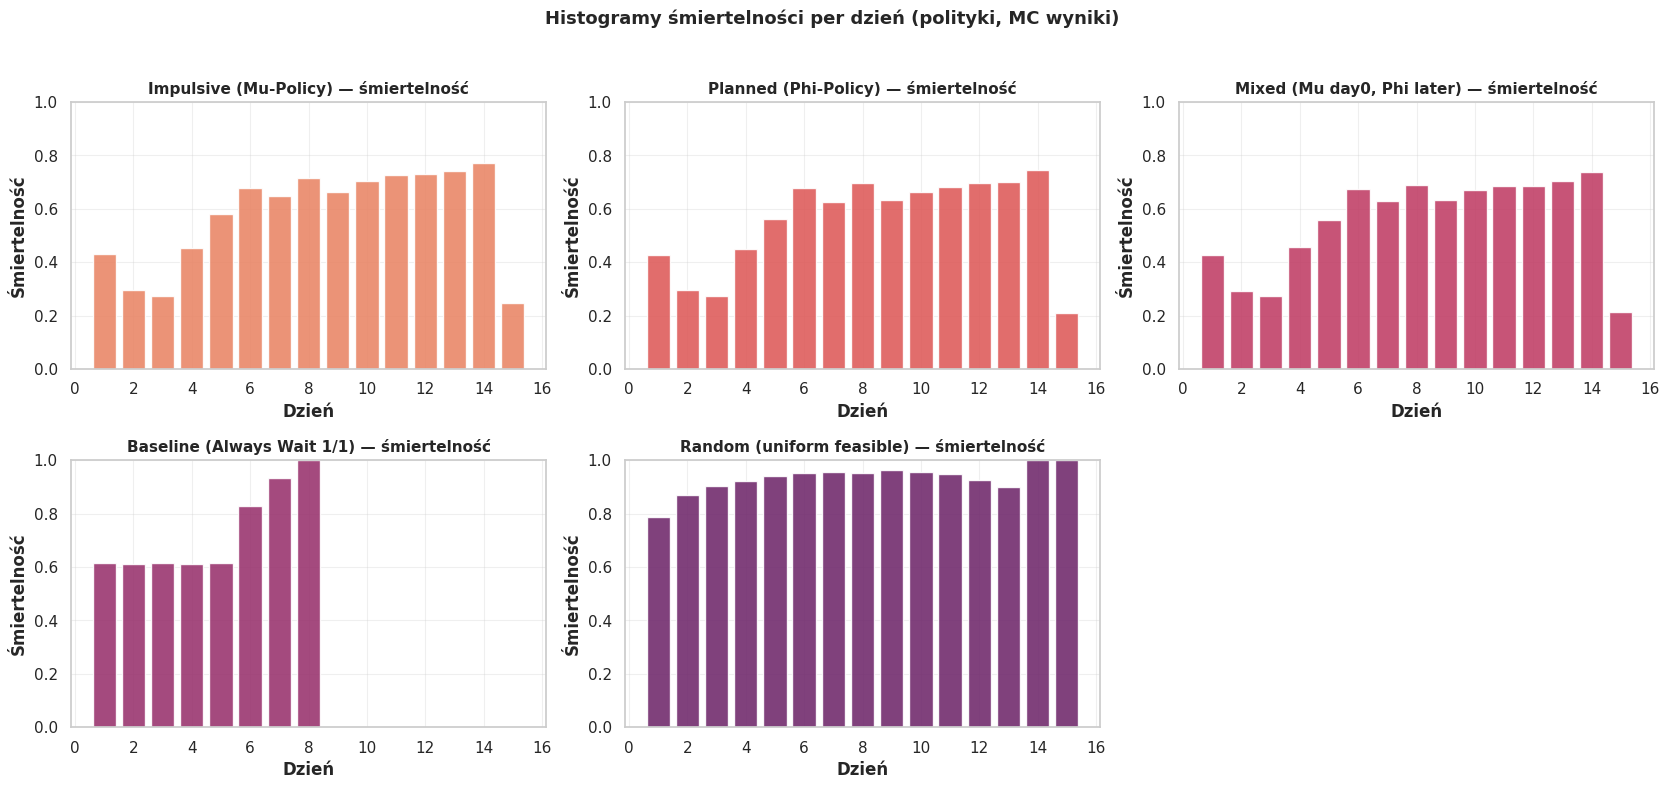

In [ ]:
# Plot per-day death histograms (death rate) for the same policies
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

required = [
    (globals().get('policy_name_mu'), globals().get('df_results_mu')),
    (globals().get('policy_name_phi'), globals().get('df_results_phi')),
    (globals().get('policy_name_mix'), globals().get('df_results_mix')),
    (globals().get('policy_name_random'), globals().get('df_results_random')),
]
policies = [(name, df) for (name, df) in required if (name is not None and isinstance(df, pd.DataFrame) and not df.empty)]
if not policies:
    raise RuntimeError("Brak wyników Monte Carlo do rysowania histogramów śmierci. Uruchom najpierw symulację.")

frames = []
for name, df in policies:
    df2 = df.copy()
    df2['death_rate'] = (df2['Deaths'] / df2['Total']).fillna(0.0)
    df2['policy'] = str(name)
    frames.append(df2[['Day', 'death_rate', 'policy']])
combined = pd.concat(frames, axis=0, ignore_index=True)
combined['Day'] = combined['Day'].astype(int)

n = len(policies)
cols = min(3, n)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5.4 * cols + 0.6, 3.8 * rows + 0.6), squeeze=False)
palette = sns.color_palette("flare", n)

for idx, (name, _) in enumerate(policies):
    ax = axes[idx // cols][idx % cols]
    dfp = combined[combined['policy'] == name]
    ax.bar(dfp['Day'], dfp['death_rate'], color=palette[idx], alpha=0.90, width=0.8, edgecolor="#ffffff")
    ax.set_title(f"{name} — śmiertelność", fontsize=11, fontweight='bold')
    ax.set_xlabel('Dzień', fontweight='semibold')
    ax.set_ylabel('Śmiertelność', fontweight='semibold')
    ax.set_ylim(0.0, 1.0)
    ax.set_facecolor('#ffffff')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, color='#cccccc')

for j in range(n, rows * cols):
    axes[j // cols][j % cols].set_visible(False)

fig.suptitle('Histogramy śmiertelności per dzień (polityki, MC wyniki)', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

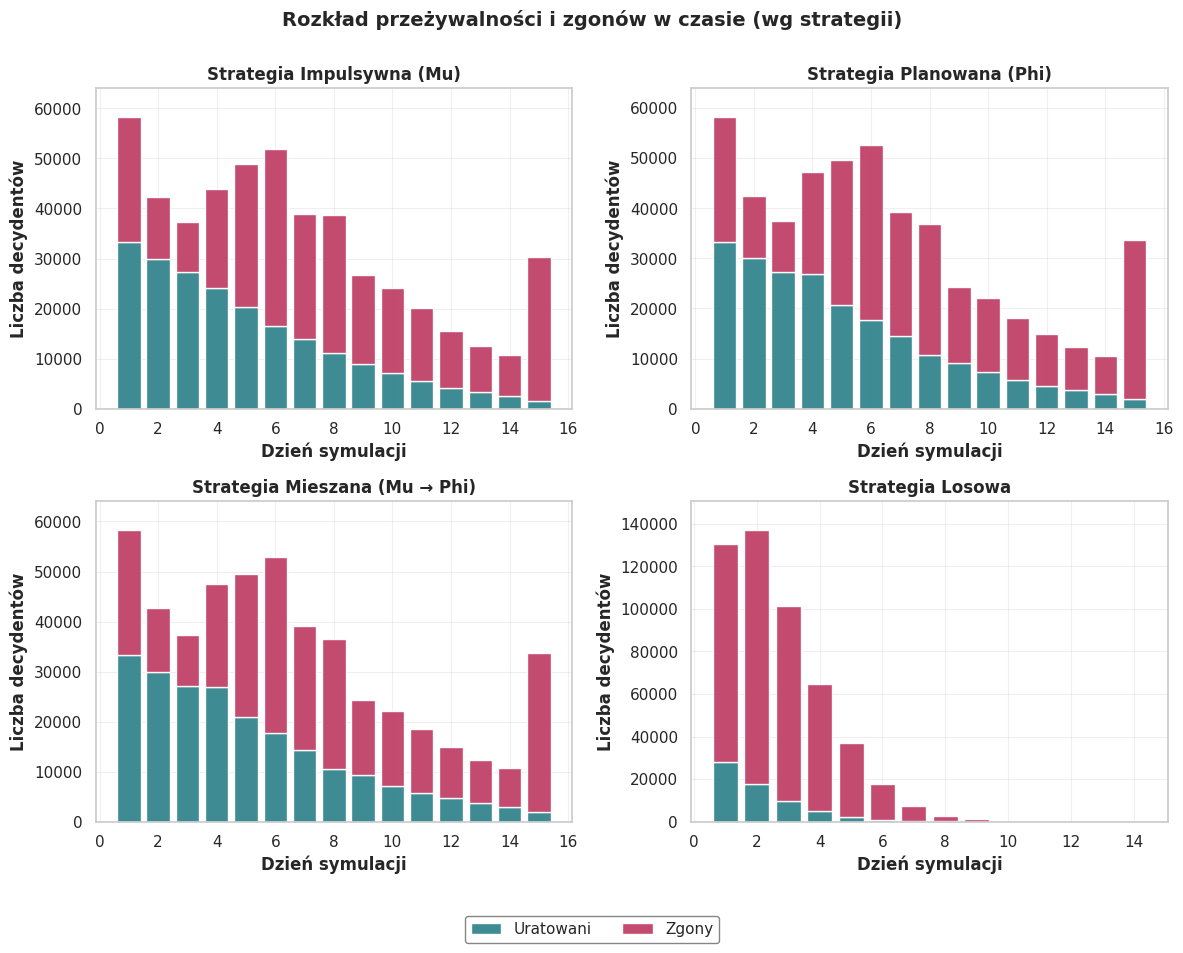

In [45]:
# Combined stacked histograms: absolute counts of survival (Rescued) and death (Deaths) per day, per policy
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Pobranie danych (bezpieczne sprawdzenie czy istnieją)
required = [
    (globals().get('policy_name_mu'), globals().get('df_results_mu')),
    (globals().get('policy_name_phi'), globals().get('df_results_phi')),
    (globals().get('policy_name_mix'), globals().get('df_results_mix')),
    (globals().get('policy_name_random'), globals().get('df_results_random')),
]
policies = [(name, df) for (name, df) in required if (name is not None and isinstance(df, pd.DataFrame) and not df.empty)]

if not policies:
    raise RuntimeError("Brak wyników Monte Carlo do rysowania wykresów. Uruchom najpierw symulację.")

# --- SŁOWNIK TŁUMACZEŃ DLA TYTUŁÓW WYKRESÓW ---
# Jeśli Twoje nazwy w zmiennych są inne, kod po prostu użyje oryginalnej nazwy
name_map = {
    "Impulsive (Mu-Policy)": "Strategia Impulsywna (Mu)",
    "Planned (Phi-Policy)": "Strategia Planowana (Phi)",
    "Mixed (Mu day0, Phi later)": "Strategia Mieszana (Mu → Phi)",
    "Baseline (Always Wait 1/1)": "Strategia Pasywna (Czekanie)",
    "Random (uniform feasible)": "Strategia Losowa"
}

n = len(policies)
cols = min(2, n)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows + 0.8), squeeze=False)

# Kolory: Uratowani (zielonkawy), Zgony (czerwonawy)
color_surv = sns.color_palette("crest", 3)[1]
color_death = sns.color_palette("flare", 3)[1]

for idx, (name, df) in enumerate(policies):
    ax = axes[idx // cols][idx % cols]

    dfp = df.copy()
    dfp['Rescued'] = dfp['Rescued'].fillna(0).astype(int)
    dfp['Deaths'] = dfp['Deaths'].fillna(0).astype(int)
    dfp['Day'] = dfp['Day'].astype(int)

    # Wykres słupkowy skumulowany (Stacked Bar)
    # Dolna część: Uratowani
    ax.bar(dfp['Day'], dfp['Rescued'], color=color_surv, alpha=0.95, width=0.8, 
           edgecolor="#ffffff", label='Uratowani')
    # Górna część: Zgony (bottom=Rescued)
    ax.bar(dfp['Day'], dfp['Deaths'], bottom=dfp['Rescued'], color=color_death, alpha=0.95, width=0.8, 
           edgecolor="#ffffff", label='Zgony')

    # Skalowanie osi Y
    totals = (dfp['Rescued'] + dfp['Deaths']).astype(float)
    max_tot = totals.max() if not totals.empty else 0
    ax.set_ylim(0, max(1, int(math.ceil(max_tot * 1.1))))

    # Tytuły i opisy
    polish_title = name_map.get(name, name)  # Tłumaczenie lub oryginał
    ax.set_title(polish_title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dzień symulacji', fontweight='semibold')
    ax.set_ylabel('Liczba decydentów', fontweight='semibold')
    
    # Stylizacja
    ax.set_facecolor('#ffffff')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, color='#cccccc')

# Ukrycie pustych osi (jeśli liczba wykresów jest nieparzysta)
for j in range(n, rows * cols):
    axes[j // cols][j % cols].set_visible(False)

# Wspólna legenda na dole
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True, 
           framealpha=0.95, edgecolor='gray', fontsize=11, bbox_to_anchor=(0.5, 0.02))

# Główny tytuł
fig.suptitle('Rozkład przeżywalności i zgonów w czasie (wg strategii)', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.show()

## Histogramy użycia akcji: wyprawy i polowania

Poniższe wykresy pokazują częstotliwość wykonywania akcji **expedition** i **hunt** w zależności od dnia symulacji, osobno dla każdej polityki (bez baseline).

**UWAGA**: Aby wykresy działały poprawnie, musisz **ponownie uruchomić komórkę Monte Carlo** (komórka #6), żeby zaktualizować dane o akcjach per dzień.

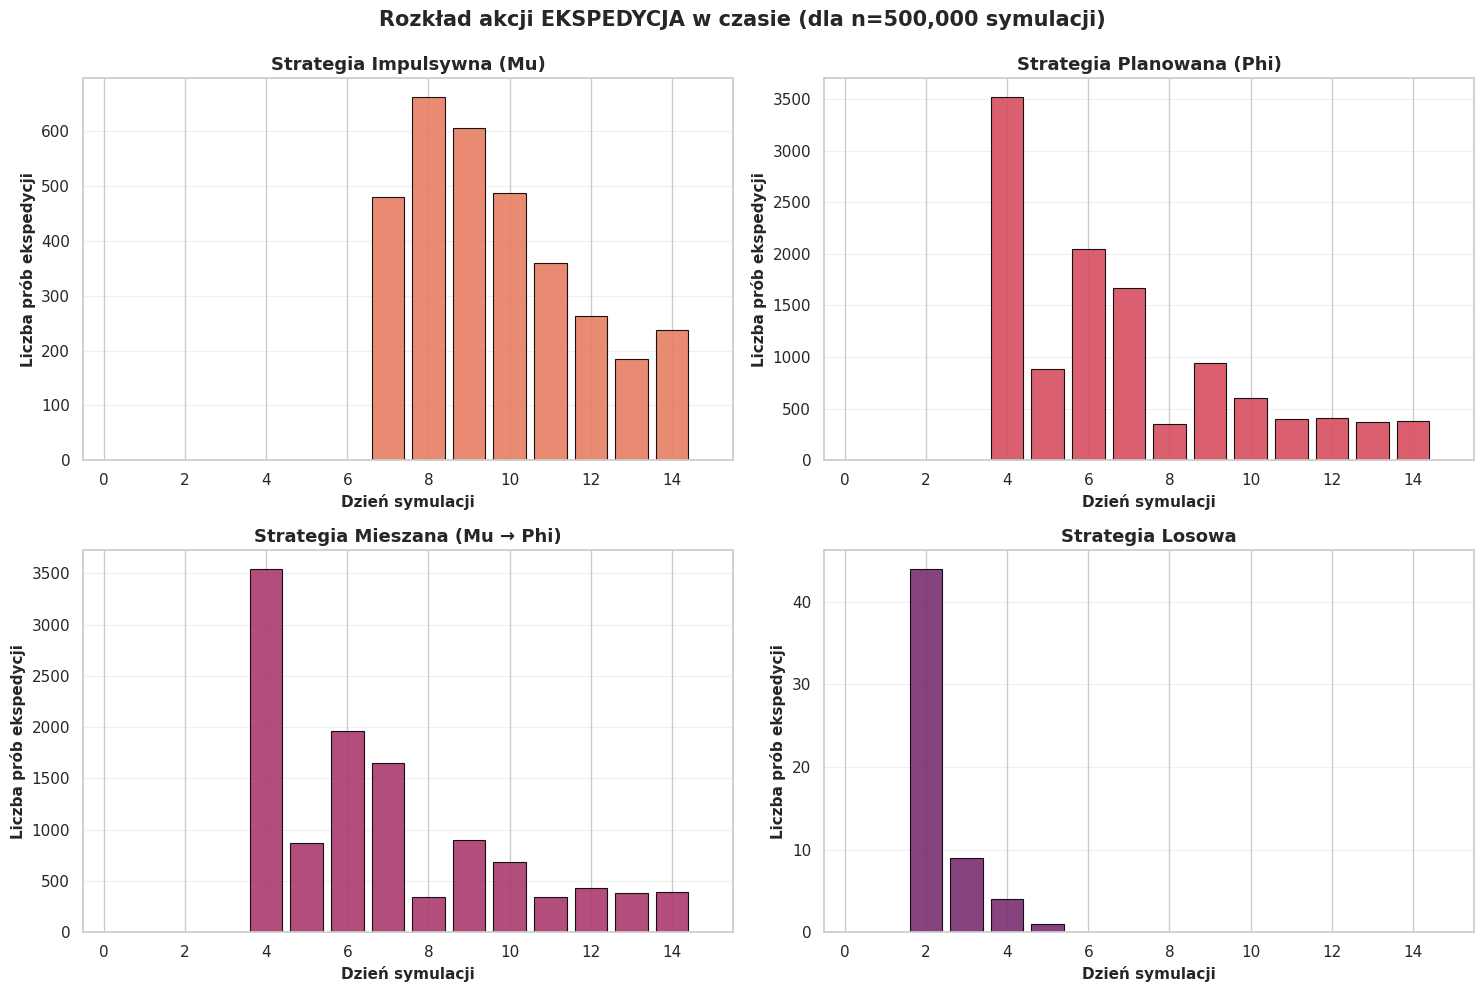

✓ Wygenerowano histogramy ekspedycji dla 4 strategii.

--- Statystyki całkowite (Suma / Średnia na agenta) ---
  Strategia Impulsywna (Mu)     :   3277 prób (0.007 per agent)
  Strategia Planowana (Phi)     :  11585 prób (0.023 per agent)
  Strategia Mieszana (Mu → Phi) :  11501 prób (0.023 per agent)
  Strategia Losowa              :     58 prób (0.000 per agent)


In [49]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# --- SŁOWNIK TŁUMACZEŃ (dla spójności) ---
name_map = {
    "Impulsive (Mu-Policy)": "Strategia Impulsywna (Mu)",
    "Planned (Phi-Policy)": "Strategia Planowana (Phi)",
    "Mixed (Mu day0, Phi later)": "Strategia Mieszana (Mu → Phi)",
    "Baseline (Always Wait 1/1)": "Strategia Pasywna (Czekanie)",
    "Random (uniform feasible)": "Strategia Losowa"
}

# Pobranie danych
required = [
    (globals().get('policy_name_mu'), globals().get('counts_mu')),
    (globals().get('policy_name_phi'), globals().get('counts_phi')),
    (globals().get('policy_name_mix'), globals().get('counts_mix')),
    (globals().get('policy_name_random'), globals().get('counts_random')),
]
policy_counts = [(name, cnts) for (name, cnts) in required if (name is not None and isinstance(cnts, dict))]

if not policy_counts:
    raise RuntimeError("Brak danych o akcjach. Uruchom najpierw symulację Monte Carlo.")

# Sprawdź czy mamy dane per-day
if 'expedition_by_day' not in policy_counts[0][1]:
    print("⚠️  BRAK DANYCH DZIENNYCH!")
    print("   Musisz ponownie uruchomić komórkę Monte Carlo (#6),")
    print("   żeby funkcja 'run_simulation_from_csv' zebrała dane o akcjach per dzień.")
    print("   Uruchom tamtą komórkę, a następnie wróć tutaj.")
else:
    # Układ 2x2
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    # Paleta kolorów
    palette = sns.color_palette("flare", 4)
    
    # Maksymalny dzień do osi X
    max_day_plot = 0
    if 'D_MAX' in globals():
        max_day_plot = D_MAX

    for idx, (name, cnts) in enumerate(policy_counts):
        ax = axes[idx]
        
        # Pobranie danych (liczba ekspedycji w danym dniu)
        # Używamy surowych liczb (counts), a nie średniej, żeby było spójnie z wykresem śmierci
        expedition_by_day = cnts.get('expedition_by_day', np.zeros(max_day_plot + 1))
        
        # Oś X
        days = np.arange(len(expedition_by_day))
        
        # Rysowanie
        bars = ax.bar(days, expedition_by_day, color=palette[idx], edgecolor='black', linewidth=0.8, alpha=0.9)
        
        # Tytuły i etykiety
        polish_title = name_map.get(name, name)
        ax.set_title(polish_title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Dzień symulacji', fontsize=11, fontweight='semibold')
        ax.set_ylabel('Liczba prób ekspedycji', fontsize=11, fontweight='semibold')
        
        # Stylizacja
        ax.grid(True, color='#cccccc', alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
        ax.set_axisbelow(True)
        ax.set_facecolor('#ffffff')
        
        # Oś X limit (trochę marginesu)
        ax.set_xlim(-0.5, max_day_plot + 0.5)
        
        # Opcjonalnie: Dodaj liczby nad słupkami jeśli są małe
        # for rect in bars:
        #     height = rect.get_height()
        #     if height > 0:
        #         ax.text(rect.get_x() + rect.get_width()/2., height,
        #                 f'{int(height)}', ha='center', va='bottom', fontsize=8)

    # Główny tytuł
    sim_count_text = ""
    if 'n_sims' in globals():
        sim_count_text = f"(dla n={n_sims:,} symulacji)"
        
    fig.suptitle(f'Rozkład akcji EKSPEDYCJA w czasie {sim_count_text}', 
                 fontsize=15, fontweight='bold', y=0.99)
    
    plt.tight_layout()
    plt.show()
    
    # Podsumowanie tekstowe
    print(f"✓ Wygenerowano histogramy ekspedycji dla {len(policy_counts)} strategii.")
    print(f"\n--- Statystyki całkowite (Suma / Średnia na agenta) ---")
    for name, cnts in policy_counts:
        exp_total = cnts.get('expedition', 0)
        polish_name = name_map.get(name, name)
        
        if 'n_sims' in globals() and n_sims > 0:
            exp_avg = exp_total / n_sims
            print(f"  {polish_name:30s}: {exp_total:6d} prób ({exp_avg:.3f} per agent)")
        else:
            print(f"  {polish_name:30s}: {exp_total:6d} prób")

### Histogramy polowań (hunt) per dzień

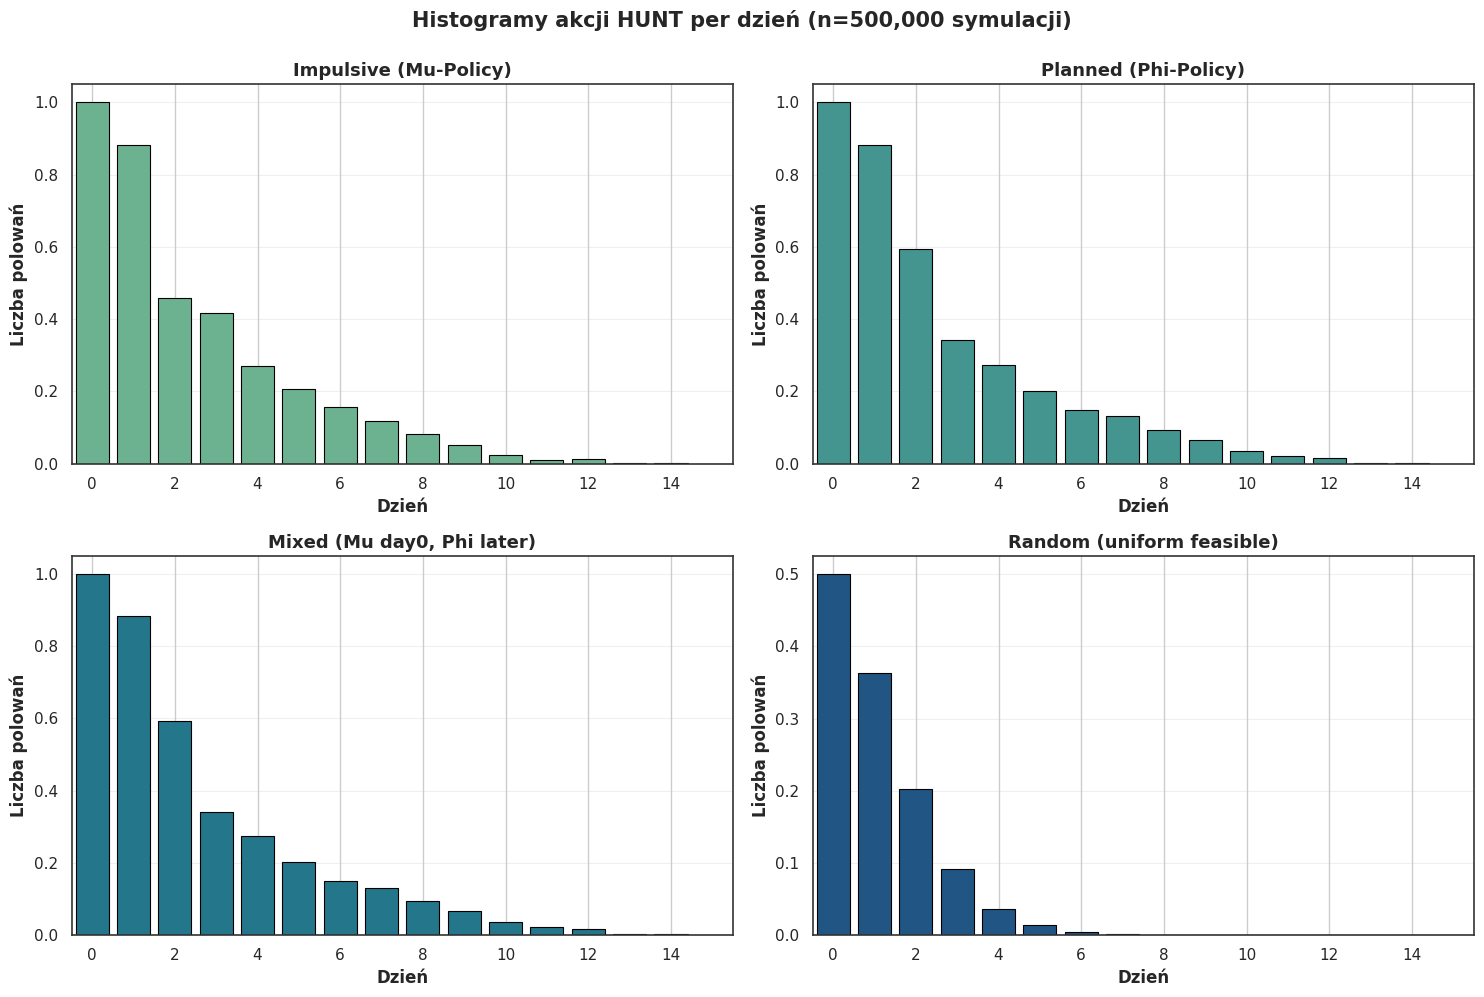

✓ Histogram hunt per dzień dla 4 polityk (bez baseline)

Statystyki całkowite:
  Impulsive (Mu-Policy)         :  1848576 hunt (3.697 per simulation)
  Planned (Phi-Policy)          :  1907110 hunt (3.814 per simulation)
  Mixed (Mu day0, Phi later)    :  1908311 hunt (3.817 per simulation)
  Random (uniform feasible)     :   606928 hunt (1.214 per simulation)


In [ ]:
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")

required = [
    (globals().get('policy_name_mu'), globals().get('counts_mu')),
    (globals().get('policy_name_phi'), globals().get('counts_phi')),
    (globals().get('policy_name_mix'), globals().get('counts_mix')),
    (globals().get('policy_name_random'), globals().get('counts_random')),
]
policy_counts = [(name, cnts) for (name, cnts) in required if (name is not None and isinstance(cnts, dict))]
if not policy_counts:
    raise RuntimeError("Brak danych o akcjach. Uruchom najpierw symulację Monte Carlo.")

# Sprawdź czy mamy dane per-day
if 'hunt_by_day' not in policy_counts[0][1]:
    print("⚠️  BRAK DANYCH PER-DAY!")
    print("   Musisz ponownie uruchomić komórkę Monte Carlo (#6),")
    print("   żeby funkcja run_simulation_from_csv zebrała dane o akcjach per dzień.")
    print("\n   Po uruchomieniu komórki #6, uruchom tę komórkę ponownie.")
else:
    # Create subplots - 2x2 layout for 4 policies
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    # Color palette
    palette = sns.color_palette("crest", 4)
    
    for idx, (name, cnts) in enumerate(policy_counts):
        ax = axes[idx]
        
        # Get fish (połowy) data per day
        hunt_by_day = cnts.get('hunt_by_day', np.zeros(D_MAX + 1))
        
        # Normalize to per-simulation average (if n_sims available)
        if 'n_sims' in globals() and n_sims > 0:
            hunt_rate = hunt_by_day / n_sims
        else:
            hunt_rate = hunt_by_day
        
        # Create bar plot
        days = np.arange(len(hunt_rate))
        bars = ax.bar(days, hunt_rate, color=palette[idx], edgecolor='black', linewidth=0.8)
        
        # Styling
        ax.set_xlabel('Dzień', fontsize=12, fontweight='semibold')
        ax.set_ylabel('Liczba połowów', fontsize=12, fontweight='semibold')
        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.grid(True, color='#cccccc', alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
        ax.set_axisbelow(True)
        ax.set_facecolor('#ffffff')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333333')
            spine.set_linewidth(1.2)
        
        # Set x-axis limits
        ax.set_xlim(-0.5, D_MAX + 0.5)
        
    # Main title
    if 'n_sims' in globals():
        fig.suptitle(f'Histogramy połowów per dzień (n={n_sims:,} symulacji)', 
                     fontsize=15, fontweight='bold', y=0.995)
    else:
        fig.suptitle('Histogramy połowów per dzień', 
                     fontsize=15, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Histogram połowów per dzień dla {len(policy_counts)} polityk (bez baseline)")
    print(f"\nStatystyki całkowite:")
    for name, cnts in policy_counts:
        hunt_total = cnts.get('hunt', 0)
        if 'n_sims' in globals() and n_sims > 0:
            hunt_avg = hunt_total / n_sims
            print(f"  {name:30s}: {hunt_total:8d} połowy (średnio {hunt_avg:.3f} na symulację)")
        else:
            print(f"  {name:30s}: {hunt_total:8d} połowy")


In [46]:
# Run Monte Carlo (no baseline) - adjust `n_sims` if needed
n_sims = 500_000
print(f"Starting Monte Carlo: n_sims={n_sims} (this may take several minutes)...")

# Run policies (no baseline)
df_results_mu, policy_name_mu, counts_mu = run_simulation_from_csv(policy_type='Mu', n_sims=n_sims, verbose=False)
df_results_phi, policy_name_phi, counts_phi = run_simulation_from_csv(policy_type='Phi', n_sims=n_sims, verbose=False)
df_results_mix, policy_name_mix, counts_mix = run_simulation_from_csv(policy_type='MuThenPhi', n_sims=n_sims, verbose=False)
df_results_random, policy_name_random, counts_random = run_simulation_from_csv(policy_type='Random', n_sims=n_sims, verbose=False)

# Print concise summaries
for name, df, cnts in [
    (policy_name_mu, df_results_mu, counts_mu),
    (policy_name_phi, df_results_phi, counts_phi),
    (policy_name_mix, df_results_mix, counts_mix),
    (policy_name_random, df_results_random, counts_random),
]:
    total = int(df['Total'].sum()) if not df.empty else 0
    rescued = int(df['Rescued'].sum()) if not df.empty else 0
    deaths = int(df['Deaths'].sum()) if not df.empty else 0
    surv = 100*rescued/total if total>0 else 0.0
    print(f"{name}: total={total}, rescued={rescued} ({surv:.2f}%), deaths={deaths}")
    print(f"  expedition total: {cnts.get('expedition',0):,d}, hunt total: {cnts.get('hunt',0):,d}")

print('\nMonte Carlo finished. Dataframes: df_results_mu/phi/mix/random; counts_* available.')

Starting Monte Carlo: n_sims=500000 (this may take several minutes)...
Impulsive (Mu-Policy): total=500000, rescued=209241 (41.85%), deaths=290759
  expedition total: 3,277, hunt total: 1,846,880
Planned (Phi-Policy): total=500000, rescued=216321 (43.26%), deaths=283679
  expedition total: 11,585, hunt total: 1,908,844
Mixed (Mu day0, Phi later): total=500000, rescued=215970 (43.19%), deaths=284030
  expedition total: 11,501, hunt total: 1,909,422
Random (uniform feasible): total=500000, rescued=64073 (12.81%), deaths=435927
  expedition total: 58, hunt total: 606,018

Monte Carlo finished. Dataframes: df_results_mu/phi/mix/random; counts_* available.


In [50]:
# Summary table: overall survival per policy
import pandas as pd
import numpy as np

policies = [
    (globals().get('policy_name_mu'), globals().get('df_results_mu'), globals().get('counts_mu')),
    (globals().get('policy_name_phi'), globals().get('df_results_phi'), globals().get('counts_phi')),
    (globals().get('policy_name_mix'), globals().get('df_results_mix'), globals().get('counts_mix')),
    (globals().get('policy_name_random'), globals().get('df_results_random'), globals().get('counts_random')),
]

rows = []
for name, df, cnts in policies:
    if name is None:
        continue
    total = np.nan
    rescued = np.nan
    deaths = np.nan
    exp_resc = np.nan
    rand_resc = np.nan

    try:
        if isinstance(df, pd.DataFrame) and not df.empty:
            total = int(df['Total'].sum())
            rescued = int(df['Rescued'].sum())
            deaths = int(df['Deaths'].sum())
        elif isinstance(cnts, dict):
            # best-effort fallback using counts dict
            rescued = int(cnts.get('rescue_total', cnts.get('expedition_rescue_total', 0) + cnts.get('random_rescue_total', 0)))
            exp_resc = int(cnts.get('expedition_rescue_total', np.nan))
            rand_resc = int(cnts.get('random_rescue_total', np.nan))
            # deaths may not be provided in counts; leave NaN if missing
            if 'total_outcomes' in globals():
                total = int(globals().get('total_outcomes', np.nan))
            else:
                total = np.nan
        else:
            total = rescued = deaths = np.nan
    except Exception:
        total = rescued = deaths = np.nan

    survival_pct = (100.0 * rescued / total) if (not np.isnan(total) and total > 0) else np.nan

    rows.append({
        'Policy': name,
        'Total': total,
        'Rescued': rescued,
        'Deaths': deaths,
        'Survival%': survival_pct,
        'ExpeditionRescues': exp_resc,
        'RandomRescues': rand_resc,
    })

summary_df = pd.DataFrame(rows)
# Format numeric columns where possible
for col in ['Total','Rescued','Deaths','ExpeditionRescues','RandomRescues']:
    if col in summary_df.columns:
        summary_df[col] = summary_df[col].apply(lambda x: int(x) if (not pd.isna(x)) else x)
summary_df['Survival%'] = summary_df['Survival%'].apply(lambda x: f"{x:.2f}%" if (not pd.isna(x)) else 'N/A')

print('\nOgólne podsumowanie przeżywalności polityk:')
print(summary_df.to_string(index=False))



Ogólne podsumowanie przeżywalności polityk:
                    Policy  Total  Rescued  Deaths Survival%  ExpeditionRescues  RandomRescues
     Impulsive (Mu-Policy) 500000   209241  290759    41.85%                NaN            NaN
      Planned (Phi-Policy) 500000   216321  283679    43.26%                NaN            NaN
Mixed (Mu day0, Phi later) 500000   215970  284030    43.19%                NaN            NaN
 Random (uniform feasible) 500000    64073  435927    12.81%                NaN            NaN
